In [1]:
# Import relevant libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# Load the data

In [4]:
data = pd.read_csv("Loan_default.csv")

In [5]:
data.head()

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255347 entries, 0 to 255346
Data columns (total 18 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   LoanID          255347 non-null  object 
 1   Age             255347 non-null  int64  
 2   Income          255347 non-null  int64  
 3   LoanAmount      255347 non-null  int64  
 4   CreditScore     255347 non-null  int64  
 5   MonthsEmployed  255347 non-null  int64  
 6   NumCreditLines  255347 non-null  int64  
 7   InterestRate    255347 non-null  float64
 8   LoanTerm        255347 non-null  int64  
 9   DTIRatio        255347 non-null  float64
 10  Education       255347 non-null  object 
 11  EmploymentType  255347 non-null  object 
 12  MaritalStatus   255347 non-null  object 
 13  HasMortgage     255347 non-null  object 
 14  HasDependents   255347 non-null  object 
 15  LoanPurpose     255347 non-null  object 
 16  HasCoSigner     255347 non-null  object 
 17  Default   

In [7]:
data.describe()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


In [8]:
# Data cleaning

In [9]:
data.isna().sum()

LoanID            0
Age               0
Income            0
LoanAmount        0
CreditScore       0
MonthsEmployed    0
NumCreditLines    0
InterestRate      0
LoanTerm          0
DTIRatio          0
Education         0
EmploymentType    0
MaritalStatus     0
HasMortgage       0
HasDependents     0
LoanPurpose       0
HasCoSigner       0
Default           0
dtype: int64

In [10]:
# Check for duplicates

In [11]:
data.duplicated().sum()

0

In [12]:
# Remove the irrelevant columns

In [13]:
data.head(2)

,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0


In [14]:
data.drop('LoanID', axis=1, inplace=True)

In [15]:
data.head(2)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0


In [16]:
numerical_columns = data.select_dtypes(include="number")

In [17]:
len(numerical_columns.columns)

10

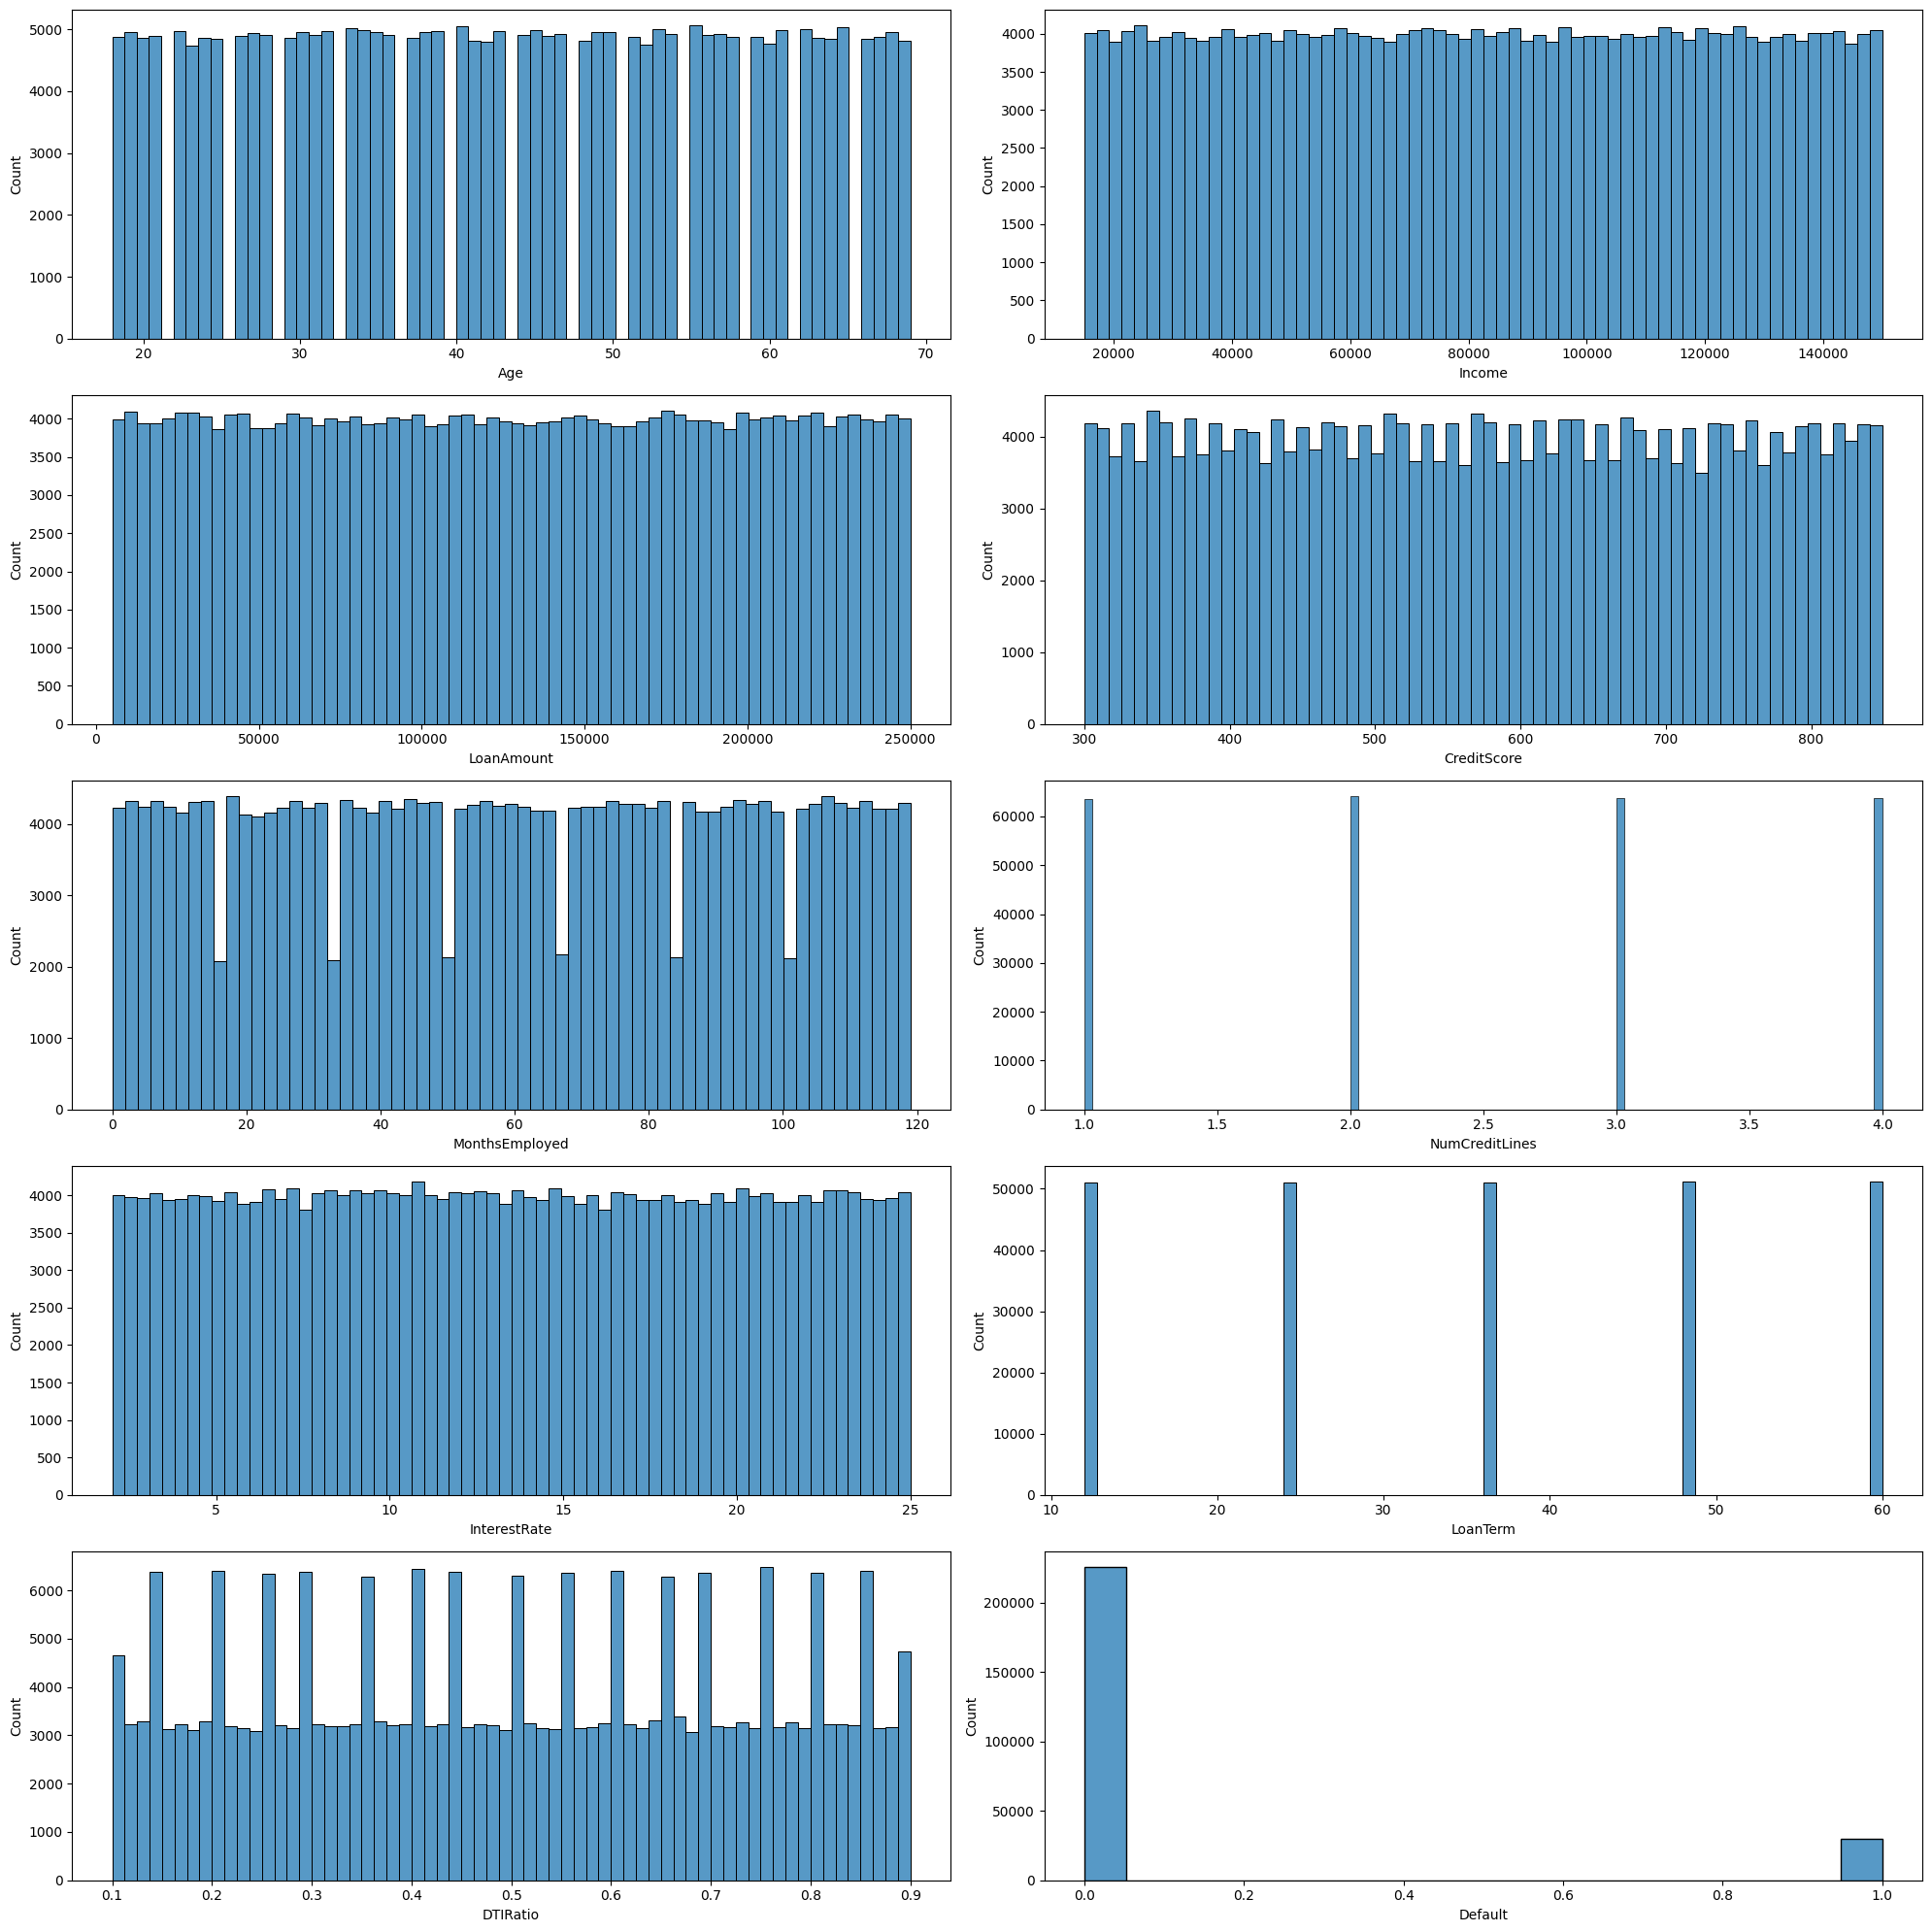

In [18]:
fig, ax = plt.subplots(nrows=5, ncols=2, figsize=(20, 20))
ax = ax.flatten()

for index, column_name in enumerate(numerical_columns):
    sns.histplot(data[column_name], ax=ax[index])

plt.tight_layout()
plt.show()

### Bivariate Analysis (Correlation Analysis)

In [19]:
correlation_map = numerical_columns.corr()

In [20]:
correlation_map

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
Age,1.000000,-0.001244,-0.002213,-0.000548,-0.000341,-0.000890,-0.001127,0.000263,-0.004689,-0.167783
Income,-0.001244,1.000000,-0.000865,-0.001430,0.002675,-0.002016,-0.002303,-0.000998,0.000205,-0.099119
LoanAmount,-0.002213,-0.000865,1.000000,0.001261,0.002817,0.000794,-0.002291,0.002538,0.001122,0.086659
CreditScore,-0.000548,-0.001430,0.001261,1.000000,0.000613,0.000016,0.000436,0.001130,-0.001039,-0.034166
MonthsEmployed,-0.000341,0.002675,0.002817,0.000613,1.000000,0.001267,0.000096,-0.001166,0.001765,-0.097374
NumCreditLines,-0.000890,-0.002016,0.000794,0.000016,0.001267,1.000000,-0.000297,-0.000226,-0.000586,0.028330
InterestRate,-0.001127,-0.002303,-0.002291,0.000436,0.000096,-0.000297,1.000000,0.000892,0.000575,0.131273
LoanTerm,0.000263,-0.000998,0.002538,0.001130,-0.001166,-0.000226,0.000892,1.000000,0.002273,0.000545
DTIRatio,-0.004689,0.000205,0.001122,-0.001039,0.001765,-0.000586,0.000575,0.002273,1.000000,0.019236
Default,-0.167783,-0.099119,0.086659,-0.034166,-0.097374,0.028330,0.131273,0.000545,0.019236,1.000000


<Axes: >

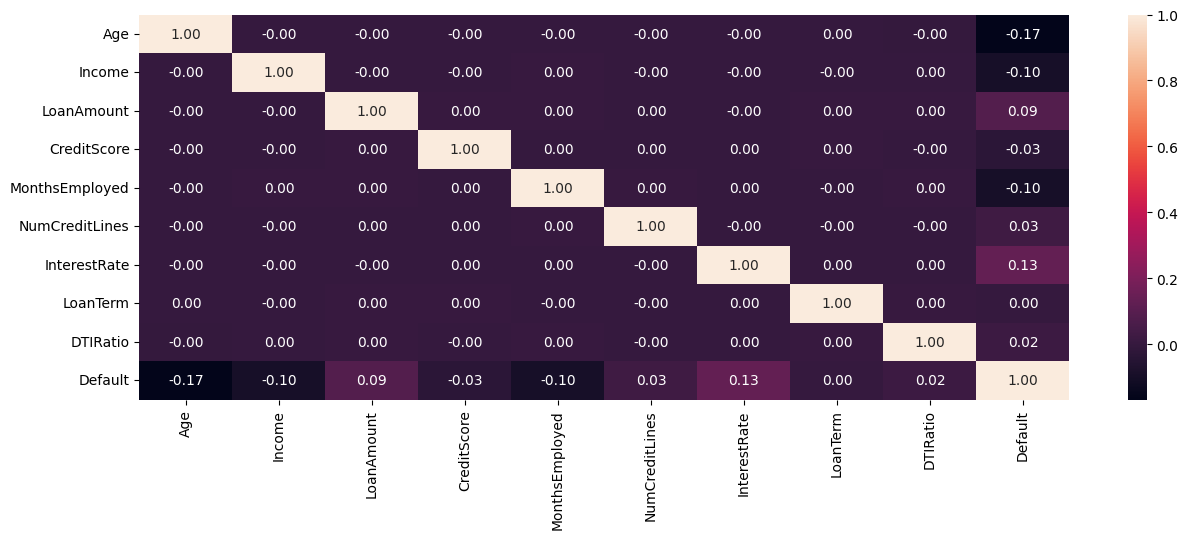

In [21]:
plt.figure(figsize=(15, 5))
sns.heatmap(correlation_map, annot=True, fmt='.2f')

### Pre-processing

In [22]:
data.head(2)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0


In [23]:
features = data.drop("Default", axis=1)

In [24]:
label = data["Default"]

In [25]:
features.head(2)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes


In [26]:
label.head(2)

0    0
1    0
Name: Default, dtype: int64

### Encoding Categorical Variables

In [27]:
features.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No


In [28]:
categorical_columns = features.select_dtypes(include="object")

In [29]:
categorical_columns.head(2)

,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes
1,Master's,Full-time,Married,No,No,Other,Yes


In [30]:
# !pip install scikit-learn

In [31]:
from sklearn.preprocessing import LabelEncoder

In [32]:
# 1. create object of the encoder

encoder = LabelEncoder()

In [33]:
# 2. fit (learning)
encoder.fit(data['Education'])

LabelEncoder()

In [34]:
encoder.transform(data['Education'])

array([0, 2, 2, ..., 1, 1, 0])

In [35]:
data['Education'].head(3)

0    Bachelor's
1      Master's
2      Master's
Name: Education, dtype: object

In [36]:
data['Education'].value_counts()

Education
Bachelor's     64366
High School    63903
Master's       63541
PhD            63537
Name: count, dtype: int64

In [37]:
# TODO: Find out how to reverse this process using sklearn LabelEncoder.

In [38]:
data['Education'] = encoder.fit_transform(data['Education'])
data['EmploymentType'] = encoder.fit_transform(data['EmploymentType'])
data['MaritalStatus'] = encoder.fit_transform(data['MaritalStatus'])

In [39]:
for column_name in categorical_columns:
    features[column_name] = encoder.fit_transform(features[column_name])

In [40]:
features.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1
2,46,84208,129188,451,26,3,21.17,24,0.31,2,3,0,1,1,0,0
3,32,31713,44799,743,0,3,7.07,24,0.23,1,0,1,0,0,1,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,3,0,0,1,0,0


### Data Splitting

In [41]:
from sklearn.model_selection import train_test_split

In [42]:
# features_train, features_test, label_train, label_test = train_test_split(features, label, test_size=0.2, random_state=42)

In [43]:
Xtrain, Xtest, ytrain, ytest = train_test_split(features, label, test_size=0.2, random_state=42)

In [44]:
# features = X variables
# label = y variables

In [45]:
Xtrain.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
137187,18,137576,209136,846,26,2,10.47,60,0.81,1,2,2,1,0,1,0
230334,47,57194,5970,748,30,2,19.72,36,0.73,1,3,0,0,1,2,0
19687,26,84328,95065,453,7,2,24.25,12,0.45,2,2,1,0,0,4,1
106509,53,49795,229582,533,107,3,14.44,60,0.17,0,2,2,1,0,0,1
242291,49,115450,22072,840,0,4,24.48,12,0.11,0,1,2,0,1,2,1


### Model Training

In [46]:
from sklearn.linear_model import LogisticRegression

In [47]:
model = LogisticRegression(random_state=42)

In [48]:
model.fit(Xtrain, ytrain)

/opt/anaconda3/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(random_state=42)

In [49]:
predictions = model.predict(Xtest) 

In [50]:
predictions[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [51]:
ytest.values[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

### Model Evaluation

In [52]:
from sklearn.metrics import classification_report, confusion_matrix

In [53]:
report = classification_report(ytest, predictions, digits=5)

In [54]:
matrix = confusion_matrix(ytest, predictions)

In [55]:
print(report)

              precision    recall  f1-score   support

           0    0.88456   0.99998   0.93873     45170
           1    0.83333   0.00085   0.00169      5900

    accuracy                        0.88455     51070
   macro avg    0.85894   0.50041   0.47021     51070
weighted avg    0.87864   0.88455   0.83048     51070



In [56]:
label.value_counts(normalize=True) * 100

Default
0    88.387175
1    11.612825
Name: proportion, dtype: float64

<Axes: xlabel='Default', ylabel='count'>

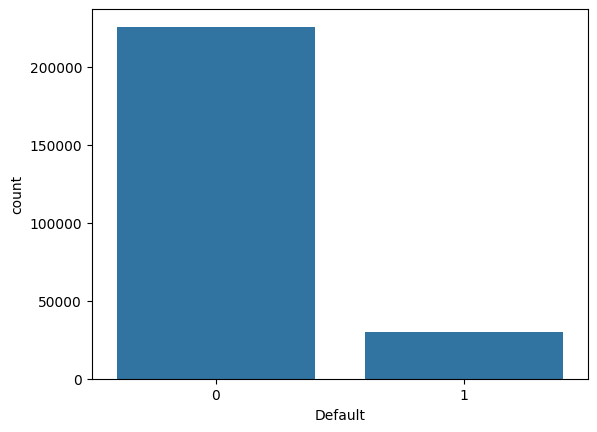

In [57]:
sns.countplot(x=data["Default"])

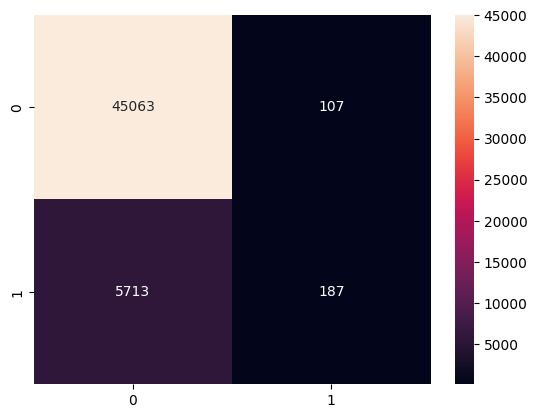

In [114]:
sns.heatmap(matrix, annot=True, fmt='g')
plt.savefig('eval_conf_matrix_1.png')
plt.show()

### TODO: Scale the values in your train and test features. And retrain the model with the scaled data.

### 

In [60]:
# Let's improve the performance of our model

In [62]:
# For uniform distribution ==> MinMaxScaler
# For normal or slightly skewed distribution ==> StandardScaler 
# For heavily skewed distribution ==> RobustScaler 

In [63]:
from sklearn.preprocessing import MinMaxScaler

In [64]:
scaler = MinMaxScaler()

In [66]:
Xtrain_scaled = scaler.fit_transform(Xtrain)
Xtest_scaled = scaler.fit_transform(Xtest)

              precision    recall  f1-score   support

           0    0.88739   0.99754   0.93925     45170
           1    0.62116   0.03085   0.05878      5900

    accuracy                        0.88586     51070
   macro avg    0.75428   0.51420   0.49901     51070
weighted avg    0.85663   0.88586   0.83753     51070



<Axes: >

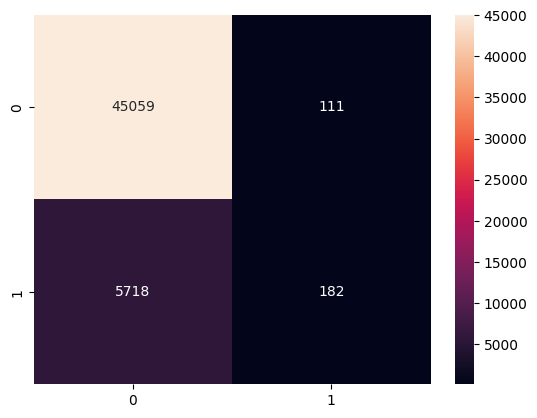

In [67]:
model = LogisticRegression(random_state=42)
model.fit(Xtrain_scaled, ytrain)
predictions = model.predict(Xtest_scaled) 
report = classification_report(ytest, predictions, digits=5)
matrix = confusion_matrix(ytest, predictions)
print(report)
sns.heatmap(matrix, annot=True, fmt='g')

In [68]:
# Can we do better?

              precision    recall  f1-score   support

           0    0.92053   0.87366   0.89648     45170
           1    0.30402   0.42254   0.35362      5900

    accuracy                        0.82154     51070
   macro avg    0.61228   0.64810   0.62505     51070
weighted avg    0.84930   0.82154   0.83376     51070



<Axes: >

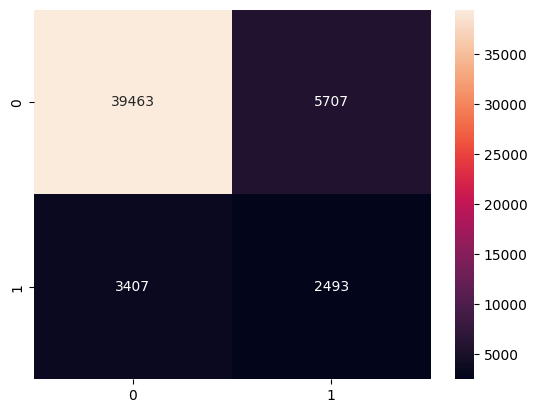

In [71]:
model = LogisticRegression(random_state=42, class_weight={0:1, 1:4})
model.fit(Xtrain_scaled, ytrain)
predictions = model.predict(Xtest_scaled) 
report = classification_report(ytest, predictions, digits=5)
matrix = confusion_matrix(ytest, predictions)
print(report)
sns.heatmap(matrix, annot=True, fmt='g')

In [72]:
# Lets try other ML algorithms

<-- Logistic Regression -->
              precision    recall  f1-score   support

           0       0.92      0.87      0.90     45170
           1       0.30      0.42      0.35      5900

    accuracy                           0.82     51070
   macro avg       0.61      0.65      0.63     51070
weighted avg       0.85      0.82      0.83     51070



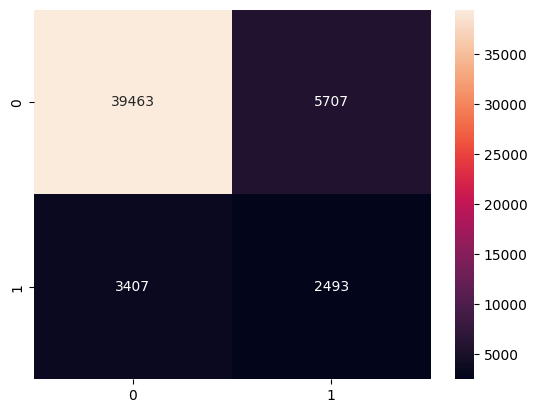

<-- SGD Classifiers -->
              precision    recall  f1-score   support

           0       0.93      0.84      0.88     45170
           1       0.28      0.48      0.36      5900

    accuracy                           0.80     51070
   macro avg       0.60      0.66      0.62     51070
weighted avg       0.85      0.80      0.82     51070



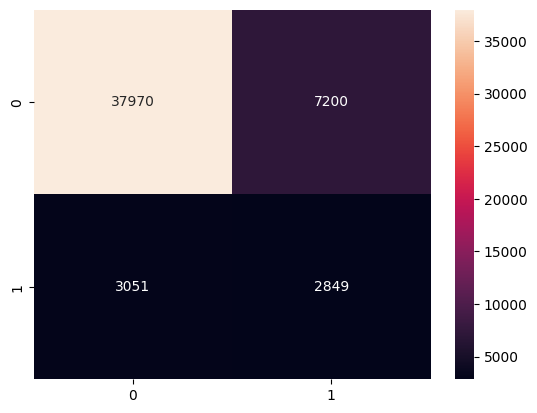

<-- Decision Tree -->
              precision    recall  f1-score   support

           0       0.90      0.89      0.89     45170
           1       0.20      0.20      0.20      5900

    accuracy                           0.81     51070
   macro avg       0.55      0.55      0.55     51070
weighted avg       0.81      0.81      0.81     51070



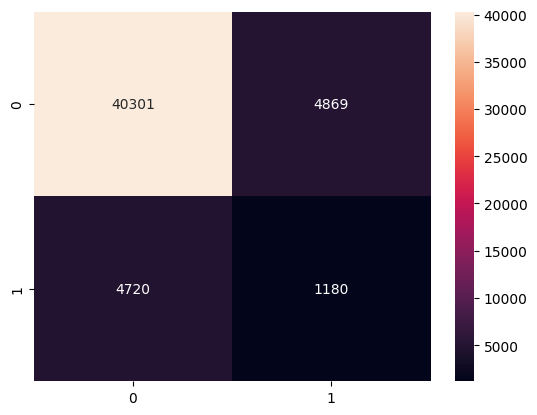

<-- Random Forest -->
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.64      0.03      0.06      5900

    accuracy                           0.89     51070
   macro avg       0.76      0.51      0.50     51070
weighted avg       0.86      0.89      0.84     51070



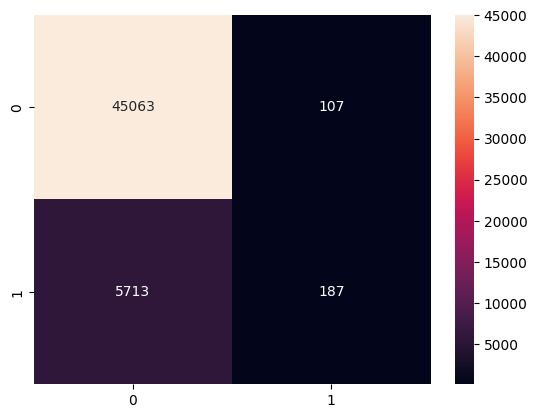

In [78]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.ensemble import RandomForestClassifier


class_weights = {0: 1, 1: 4} 

# Initialize and train the models
classifiers = [[LogisticRegression(random_state=42, class_weight=class_weights), 'Logistic Regression'],
               [SGDClassifier(random_state=42, class_weight=class_weights), 'SGD Classifiers'],
               [DecisionTreeClassifier(random_state=42, class_weight=class_weights), 'Decision Tree'],
               [RandomForestClassifier(random_state=42, class_weight=class_weights), 'Random Forest'],
              ]

for classifier in classifiers:
    model_name = classifier[1]
    model = classifier[0]
    print(f"<-- {model_name} -->")
    model.fit(Xtrain_scaled, ytrain)
    predictions = model.predict(Xtest_scaled)
    report = classification_report(ytest, predictions)
    matrix = confusion_matrix(ytest, predictions)
    print(report)
    sns.heatmap(matrix, annot=True, fmt='g')
    plt.show()

In [79]:
# Feature Selection Phase

In [80]:
# ExplainableAI (XAI)

In [81]:
# Feature Importance

In [87]:
classifiers[3][0].feature_importances_

array([0.12346932, 0.13011049, 0.11530581, 0.09621592, 0.10052636,
       0.0294051 , 0.13167643, 0.03562807, 0.08444316, 0.02935622,
       0.0285231 , 0.02304097, 0.01337598, 0.01225826, 0.035622  ,
       0.0110428 ])

In [89]:
features.head(2)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,1,1,4,1
1,69,50432,124440,458,15,1,4.81,60,0.68,2,0,1,0,0,4,1


In [90]:
importances = classifiers[3][0].feature_importances_
feat_col = features.columns

In [91]:
feature_importance_df = pd.DataFrame({'Features':feat_col, 'Importances':importances})

In [93]:
feature_importance_df

,Features,Importances
0,Age,0.123469
1,Income,0.130110
2,LoanAmount,0.115306
3,CreditScore,0.096216
4,MonthsEmployed,0.100526
5,NumCreditLines,0.029405
6,InterestRate,0.131676
7,LoanTerm,0.035628
8,DTIRatio,0.084443
9,Education,0.029356


In [94]:
feature_importance_df = feature_importance_df.sort_values(by='Importances', ascending=False)

In [95]:
feature_importance_df

,Features,Importances
6,InterestRate,0.131676
1,Income,0.130110
0,Age,0.123469
2,LoanAmount,0.115306
4,MonthsEmployed,0.100526
3,CreditScore,0.096216
8,DTIRatio,0.084443
7,LoanTerm,0.035628
14,LoanPurpose,0.035622
5,NumCreditLines,0.029405


(array([0.  , 0.02, 0.04, 0.06, 0.08, 0.1 , 0.12, 0.14]),
 [Text(0.0, 0, '0.00'),
  Text(0.02, 0, '0.02'),
  Text(0.04, 0, '0.04'),
  Text(0.06, 0, '0.06'),
  Text(0.08, 0, '0.08'),
  Text(0.1, 0, '0.10'),
  Text(0.12, 0, '0.12'),
  Text(0.14, 0, '0.14')])

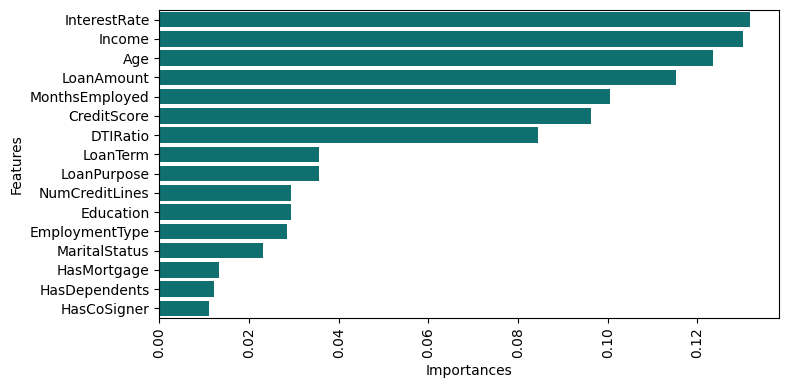

In [103]:
plt.figure(figsize=(8, 4))
sns.barplot(y='Features', x='Importances', data=feature_importance_df, color='teal')
plt.xticks(rotation=90)

In [104]:
# Train with top-5 or top-n

In [105]:
# Hyper-parameter tuning

In [106]:
from sklearn.model_selection import GridSearchCV

In [108]:
parameter_grid = {
    'max_depth': [20, 30, 40],
    'min_samples_split': [2, 5, 7],
    'n_estimators': [100, 120, 150],
    'class_weight': [{0:1, 1:2}, {0:1, 1:3}, {0:1, 1:5}]
}

In [110]:
grid_search = GridSearchCV(
    classifiers[3][0],
    param_grid=parameter_grid,
    cv=5,
    scoring='f1'
)

In [1]:
grid_search.fit(Xtrain_scaled, ytrain)

In [ ]:
grid_search.best_params_

In [107]:
RandomForestClassifier()

sklearn.ensemble._forest.RandomForestClassifier

In [109]:
classifiers[3][0]

RandomForestClassifier(class_weight={0: 1, 1: 4}, random_state=42)